## LRModelEva

In [1]:
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from evaluation_utils import (
    load_yelp_split,
    print_evaluation,
    print_top_terms,
    validate_pipeline_labels,
)


PART_B_DIR = Path.cwd().parents[0]
DATA_FILE = PART_B_DIR / "data" / "yelp_clean.csv"
MODEL_FILE = PART_B_DIR / "models" / "lr_tuned.joblib"

### Load Tuned Model

In [2]:
# Reload the tuned Yelp Logistic Regression pipeline saved by Q3.
pipeline = joblib.load(MODEL_FILE)
validate_pipeline_labels(pipeline, "Logistic Regression")

### Model Evaluation

In [3]:
# Recreate the same held-out test set used throughout Part B.
df, X_train, X_test, y_train, y_test = load_yelp_split(DATA_FILE)

print_top_terms(pipeline, X_train, y_train, "Logistic Regression")
print_evaluation(pipeline, X_test, y_test, "Logistic Regression")

=== Top Terms Per Sentiment Class (Logistic Regression) ===

negative:
not, horrible, terrible, bland, no, waste, rude, bad, mediocre, disappointed

neutral:
decent, okay, ok, good, star, bit, though, average, however, pretty

positive:
great, delicious, amaze, love, best, awesome, excellent, perfect, favorite, fantastic

=== Q4: Tuned Yelp Logistic Regression 3-Class Classification Report ===
              precision    recall  f1-score   support

    negative     0.8282    0.7854    0.8062      2400
     neutral     0.4465    0.5708    0.5011      1200
    positive     0.8457    0.7717    0.8070      2400

    accuracy                         0.7370      6000
   macro avg     0.7068    0.7093    0.7048      6000
weighted avg     0.7589    0.7370    0.7455      6000

=== Q4: Tuned Yelp Logistic Regression Summary ===
Accuracy:        0.7370
Macro Precision: 0.7068
Macro Recall:    0.7093
Macro F1-score:  0.7048
Weighted F1:     0.7455

=== Q4: Tuned Yelp Logistic Regression Confusion M

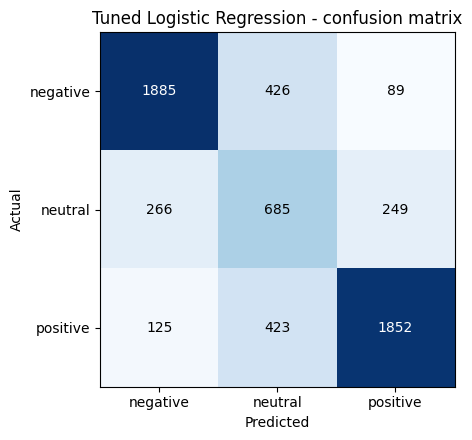

negative predicted as positive: 89
positive predicted as negative: 125
neutral missed entirely       : 515 of 1200


In [4]:
# Same confusion matrix as above, drawn as a labelled grid so it can go in the report.
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, pipeline.predict(X_test), labels=labels)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(3), labels)
ax.set_yticks(range(3), labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Tuned Logistic Regression - confusion matrix")

# Write the count into each square, in white on the darker cells so it stays readable.
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.savefig("lr_confusion_matrix.png", dpi=120)
plt.show()

# The two polar classes are rarely confused with each other; nearly all the error is
# neutral being pulled toward one of the poles, or a pole being called neutral.
print("negative predicted as positive:", cm[0, 2])
print("positive predicted as negative:", cm[2, 0])
print("neutral missed entirely       :", cm[1, 0] + cm[1, 2], "of", cm[1].sum())